# Homework 10 — Object Tracking Comparison (KCF vs CSRT)

This notebook tracks the same object using two OpenCV trackers:
- KCF
- CSRT

Steps:
1. Upload a video
2. Define a bounding box
3. Run KCF tracker for 15 frames
4. Run CSRT tracker for 15 frames
5. Compare results


In [1]:
!pip install opencv-contrib-python

In [2]:
from google.colab import files
uploaded = files.upload()

Saving video.mp4 to video.mp4


In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Set the video filename

In [4]:
video_path = 'video.mp4'

First frame to help choose the bounding box.

(np.float64(-0.5), np.float64(1279.5), np.float64(575.5), np.float64(-0.5))

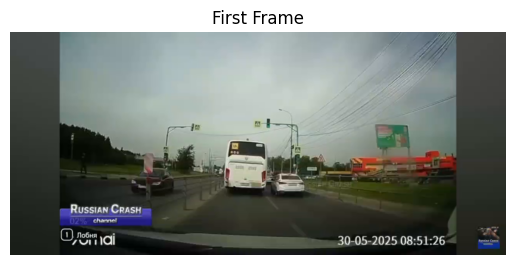

In [25]:
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title('First Frame')
plt.axis('off')

Define bounding box

In [29]:
bbox = (560, 285, 110, 135)

## KCF Tracker

In [43]:
tracker = cv2.TrackerKCF_create()

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()

tracker.init(frame, bbox)

frames_kcf = []

for i in range(15):
    ret, frame = cap.read()
    if not ret:
        break

    success, box = tracker.update(frame)

    if success:
        x,y,w,h = [int(v) for v in box]
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)

    frames_kcf.append(frame)

cap.release()

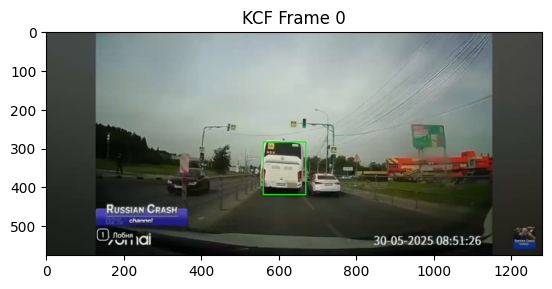

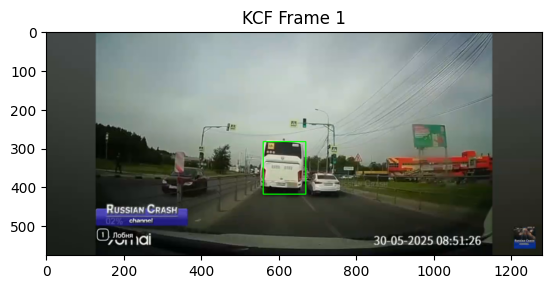

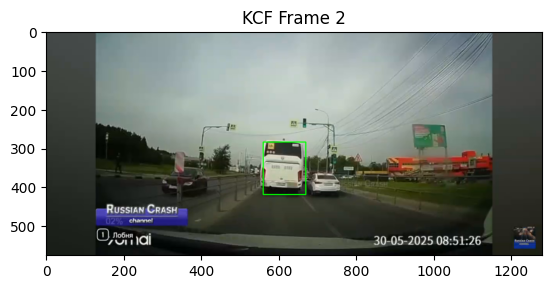

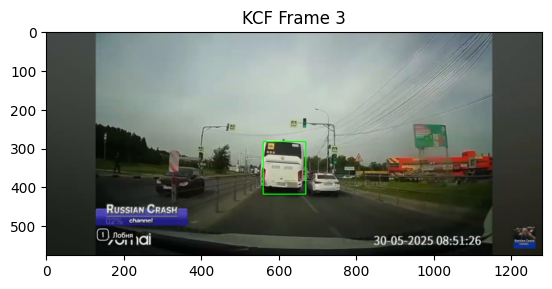

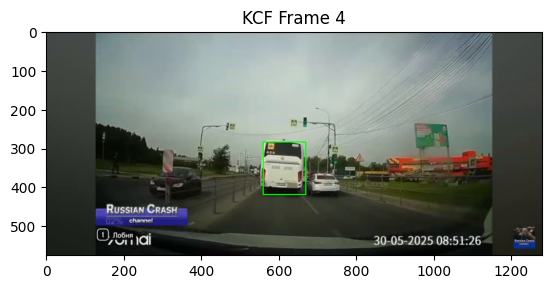

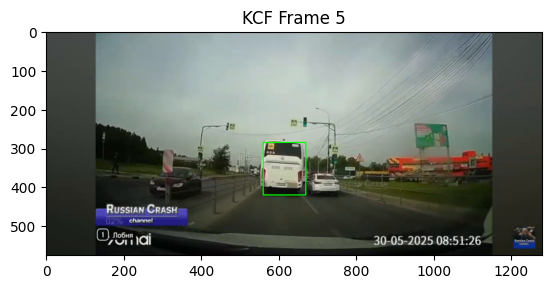

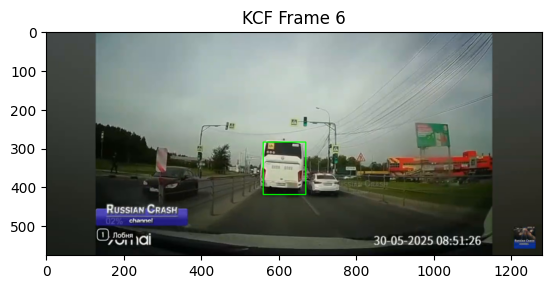

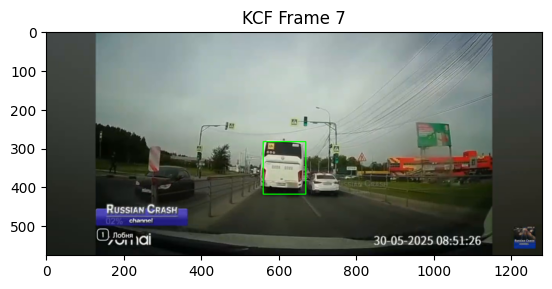

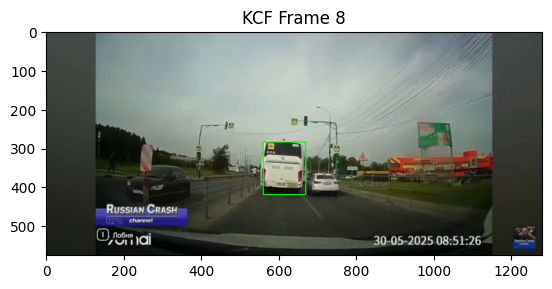

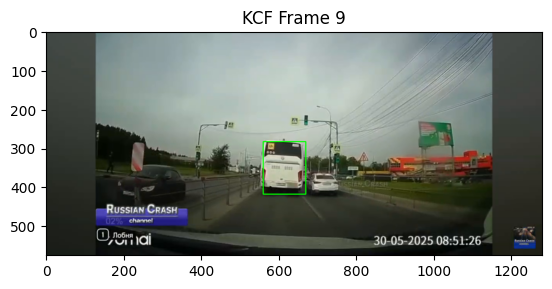

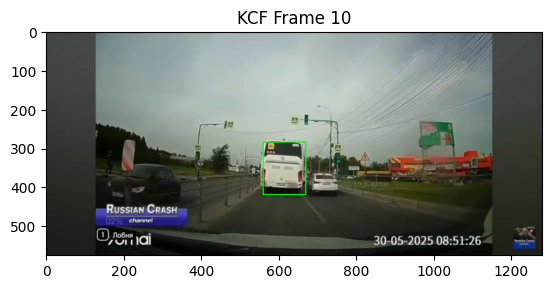

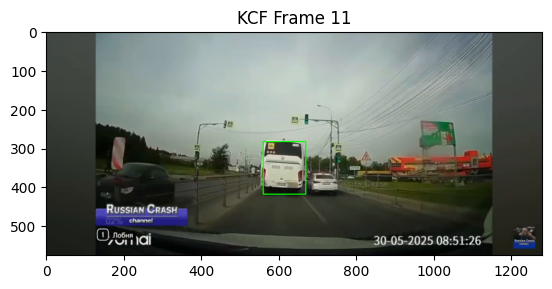

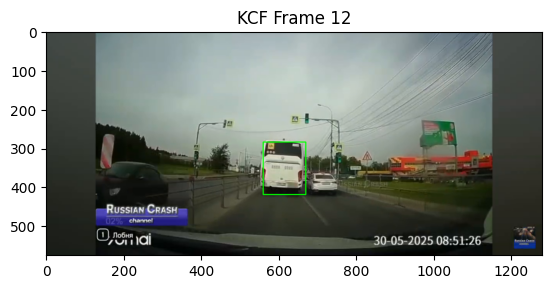

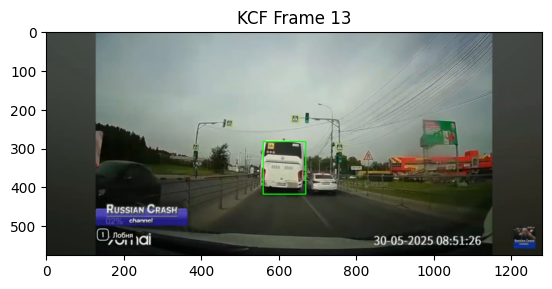

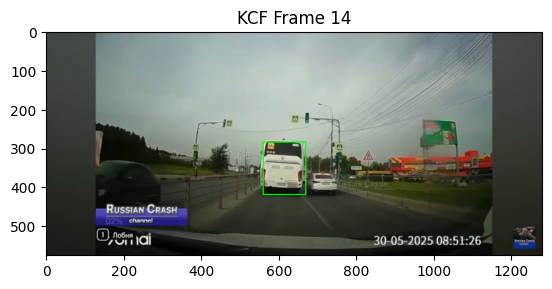

In [44]:
for i,frame in enumerate(frames_kcf):
    plt.figure()
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f'KCF Frame {i}')
    plt.axis('on')

## CSRT Tracker

In [33]:
tracker = cv2.TrackerCSRT_create()

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()

tracker.init(frame, bbox)

frames_csrt = []

for i in range(15):
    ret, frame = cap.read()
    if not ret:
        break

    success, box = tracker.update(frame)

    if success:
        x,y,w,h = [int(v) for v in box]
        cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)

    frames_csrt.append(frame)

cap.release()

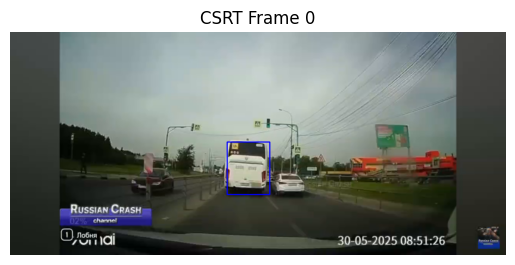

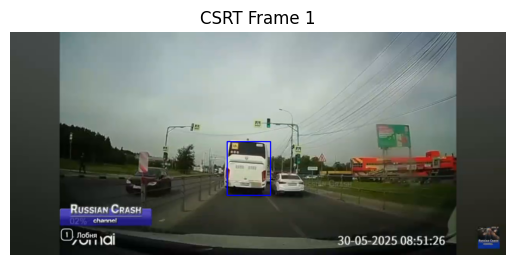

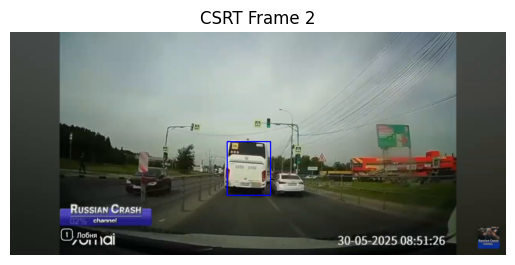

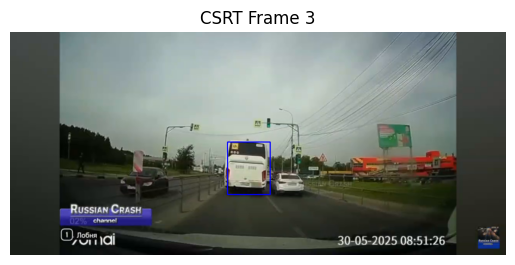

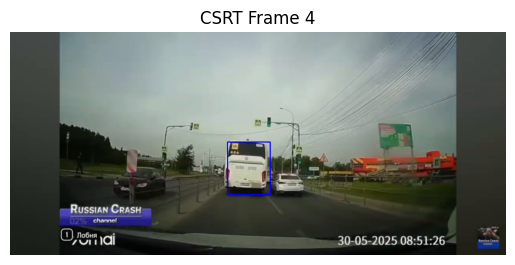

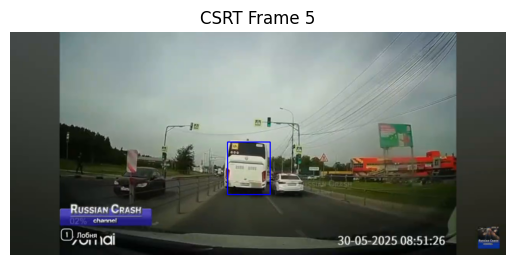

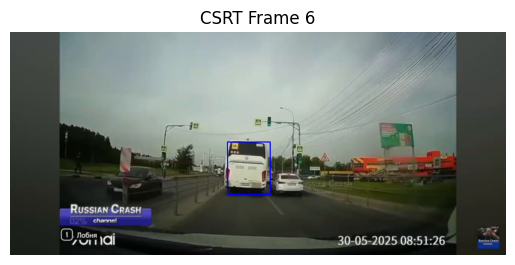

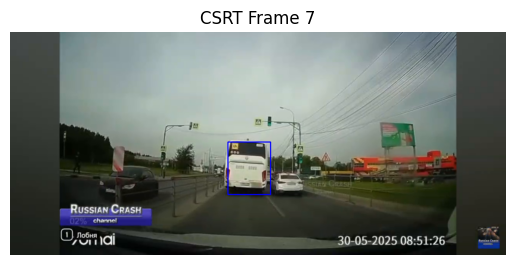

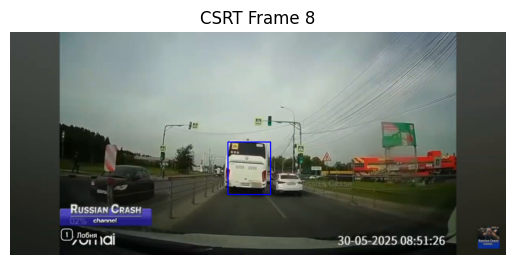

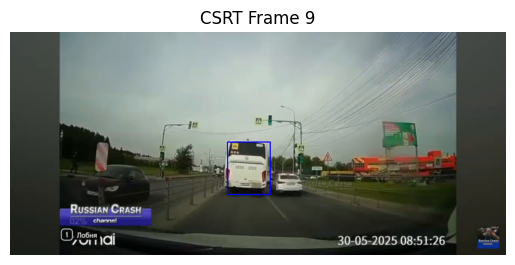

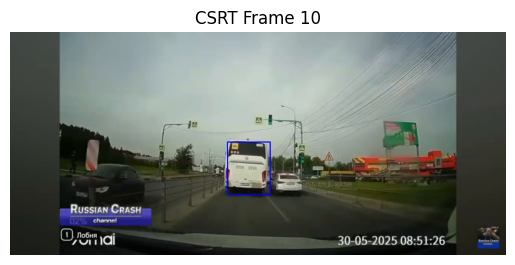

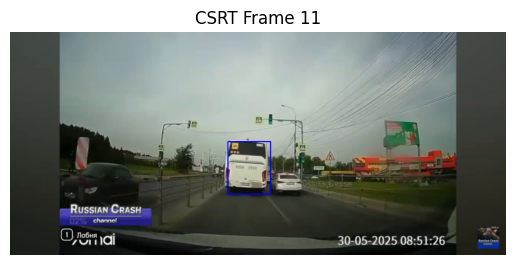

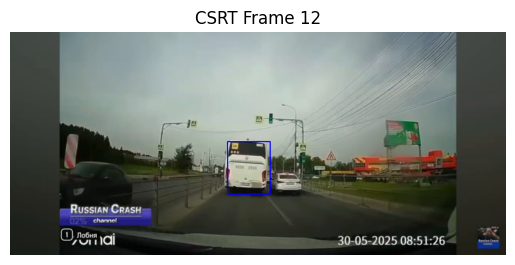

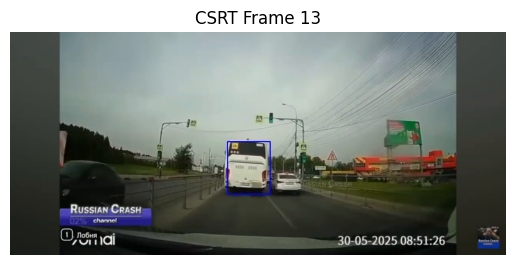

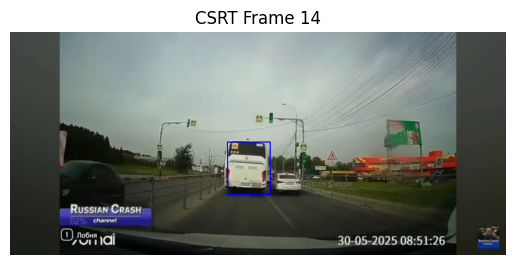

In [37]:
for i,frame in enumerate(frames_csrt):
    plt.figure()
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f'CSRT Frame {i}')
    plt.axis('off')

Трекер KCF работает быстрее, в то время как трекер CSRT обеспечивает более стабильное и точное отслеживание. В этом эксперименте было проанализировано всего 15 кадров, чего визуально недостаточно для четкого наблюдения разницы между трекерами. Однако, если количество обработанных кадров увеличить, разница станет более заметной, и CSRT поддерживает более стабильную ограничивающую рамку вокруг отслеживаемого объекта.